In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import missingno as msno
from collections import Counter

In [2]:
df = pd.read_csv("../data/BMW/eng_ger_auto_reviews_dataset.csv", encoding="utf-8")
#In EDA arbeiten wir mit bereits bereinigten Daten. Die Rohdaten-Bereinigung gehört ins Preprocessing. 
print(f"Dataset geladen: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset geladen: 21721 rows, 12 columns


In [3]:
rows, cols= df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 21721
Columns: 12


In [4]:
df.info(memory_usage="deep")
#mit memory_usage sehen wir zusätzlich den Speicherverbrauch

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21721 entries, 0 to 21720
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              21721 non-null  object
 1   userName              21721 non-null  object
 2   userImage             21721 non-null  object
 3   content               21718 non-null  object
 4   score                 21721 non-null  int64 
 5   thumbsUpCount         21721 non-null  int64 
 6   reviewCreatedVersion  20492 non-null  object
 7   at                    21721 non-null  object
 8   replyContent          5372 non-null   object
 9   repliedAt             5372 non-null   object
 10  appVersion            20492 non-null  object
 11  company               21721 non-null  object
dtypes: int64(2), object(10)
memory usage: 19.5 MB


In [5]:
df.head()
df.sample(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company
13056,b454e277-3a8d-477c-814f-824558512280,ion zarafea,https://play-lh.googleusercontent.com/a/ACg8oc...,5 stars,5,0,3.11.3,2024-01-21 13:59:45,NaN,NaN,3.11.3,BMW
21503,e35a0e7b-2982-45d7-a3c3-f46135002e21,Matty B,https://play-lh.googleusercontent.com/a/ACg8oc...,Spotify broke integration about a year ago how...,1,1,NaN,2021-04-06 15:25:28,NaN,NaN,NaN,BMW
10798,41bc70a4-e68d-41d9-8ab8-1a528be61099,Carsten Knuetter,https://play-lh.googleusercontent.com/a-/ALV-U...,Mein BMW ist Baujahr 2018. Ihre Antwort ist so...,1,1,1.2.2,2020-12-30 16:53:45,"Hallo Carsten! Die Funktion ""Ziel an meinen BM...",2021-01-05 17:28:58,1.2.2,BMW
18536,5f5cb2cf-f7f8-4936-8ed8-af17562655ac,RK Tooling,https://play-lh.googleusercontent.com/a-/ALV-U...,I am very lucky. people respect the car more t...,5,0,3.11.3,2023-12-10 01:45:07,NaN,NaN,3.11.3,BMW
13259,912624aa-8a08-4ef0-9c5c-5007835bece5,Patrick Bhekubuhle Buthelezi,https://play-lh.googleusercontent.com/a-/ALV-U...,Hi thanks you are very quick to respond.,5,0,3.9.3,2023-11-13 18:12:49,NaN,NaN,3.9.3,BMW


In [6]:
#Ursprüngliche Versionen wurde ergänzt mit klarem Kontext. vorher df["review"].nunique()
total_reviews = len(df)
unique_reviews = df["reviewId"].nunique()

print(f"Total reviews: {total_reviews}")
print(f"Unique review IDs: {unique_reviews}")

Total reviews: 21721
Unique review IDs: 11009


##### Das Dataset enthält 21,721 Reviews, jedoch nur 11,009 eindeutige reviewIds.Dies deutet auf eine erhebliche Anzahl von Duplikaten hin, die im nächsten Schritt analysiert werden.Anschließend prüfen wir unten, ob die Zeilen tatsächlich identisch sind. Hier stellen wir fest, dass zumindest für die erste reviewID drei reviews erzeugt wurden jedoch die Inhalte der Spalten alle identisch sind.

In [7]:
# Validierung: Datenintegrität prüfen
assert df.shape[0] > 1000, "Dataset zu klein – überprüfe Datenquelle"
assert df['reviewId'].nunique() > 5000, "Zu wenige unique Reviews – mögliche Duplikate"
print(f"✅ Datenvalidierung erfolgreich: {df.shape[0]} Zeilen, {df['reviewId'].nunique()} unique Reviews")

#Fügt automatische Checks hinzu, die Fehler früh erkennen. 
#Für Streamlit wichtig, um sicherzustellen, dass die Daten korrekt geladen sind.

✅ Datenvalidierung erfolgreich: 21721 Zeilen, 11009 unique Reviews


In [8]:
duplicate_reviews = df[df.duplicated(subset="reviewId", keep=False)]
duplicate_reviews.sort_values("reviewId")

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company
4613,0009649e-29e2-4e53-b934-12e15bc40a64,clemens auer,https://play-lh.googleusercontent.com/a/ACg8oc...,"Unfortunately really bad experience, at some p...",3,1,1.5.2,2021-08-14 15:59:40,Hi Clemens! Our development team is working on...,2021-08-17 12:15:50,1.5.2,BMW
20978,0009649e-29e2-4e53-b934-12e15bc40a64,clemens auer,https://play-lh.googleusercontent.com/a/ACg8oc...,"Unfortunately really bad experience, at some p...",3,1,1.5.2,2021-08-14 15:59:40,Hi Clemens! Our development team is working on...,2021-08-17 12:15:50,1.5.2,BMW
15622,0009649e-29e2-4e53-b934-12e15bc40a64,clemens auer,https://play-lh.googleusercontent.com/a/ACg8oc...,"Unfortunately really bad experience, at some p...",3,1,1.5.2,2021-08-14 15:59:40,Hi Clemens! Our development team is working on...,2021-08-17 12:15:50,1.5.2,BMW
3636,001096d3-b5aa-491a-941a-81ced995aca1,Bobby,https://play-lh.googleusercontent.com/a-/ALV-U...,Give you all the information on your Bmw.,5,0,2.5.2,2022-05-30 18:08:17,NaN,NaN,2.5.2,BMW
20001,001096d3-b5aa-491a-941a-81ced995aca1,Bobby,https://play-lh.googleusercontent.com/a-/ALV-U...,Give you all the information on your Bmw.,5,0,2.5.2,2022-05-30 18:08:17,NaN,NaN,2.5.2,BMW
...,...,...,...,...,...,...,...,...,...,...,...,...
18242,ffd49ed0-c87a-4cd9-92ab-89f7f143c186,Clive Saddler,https://play-lh.googleusercontent.com/a/ACg8oc...,The App has been very reliable in the twio yea...,4,0,4.3.2,2024-04-04 07:14:12,NaN,NaN,4.3.2,BMW
12886,ffd49ed0-c87a-4cd9-92ab-89f7f143c186,Clive Saddler,https://play-lh.googleusercontent.com/a/ACg8oc...,The App has been very reliable in the twio yea...,4,0,4.3.2,2024-04-04 07:14:12,NaN,NaN,4.3.2,BMW
20689,ffec6f78-52c8-405a-8ebb-6365157f61d1,Vijay Vekaria,https://play-lh.googleusercontent.com/a/ACg8oc...,App features sometimes don't work. No rhyme or...,2,0,1.6.2,2021-10-23 23:28:06,NaN,NaN,1.6.2,BMW
15333,ffec6f78-52c8-405a-8ebb-6365157f61d1,Vijay Vekaria,https://play-lh.googleusercontent.com/a/ACg8oc...,App features sometimes don't work. No rhyme or...,2,0,1.6.2,2021-10-23 23:28:06,NaN,NaN,1.6.2,BMW


In [9]:
dup_counts = df.groupby("reviewId").size().sort_values(ascending=False)
dup_counts.head(10)

reviewId
d586763c-87f5-48ec-8c9d-8592ffbfb0a3    3
581fe4ee-b7a6-4c08-a7b4-5a41b8271149    3
92ee866d-8f56-4e5f-8b4c-b5e66056ce6a    3
58467ea6-c966-4fa2-b6ad-29f588fd3035    3
58457b84-39a2-4d27-8b29-87b580a4f5c0    3
92efbee2-cc2b-4113-9d9b-3f56de4ba353    3
583ee1f8-7762-4309-ae5d-f05c67c3641b    3
d3f785ff-3bf8-49da-9313-6763ffeacf2a    3
583988fc-6671-49da-8603-2015337447c2    3
58239a94-cdb8-48f4-9f59-4d307ead1ed8    3
dtype: int64

##### Wir prüfen nun, ob sich Duplikate nur im Datensatz wiederholen oder ob sich Inhalte (Score, Text, Zeitstempel) unterscheiden.

In [10]:
score_variation = df.groupby("reviewId")["score"].nunique()
score_variation.value_counts()
#Wenn ein Wert >1 ist, bedeutet dies, dass ein Review mit derselben reviewId unterschiedliche Scores besitzt.
#1=identisch
#2=verändert

score
1    11009
Name: count, dtype: int64

In [11]:
content_variation = df.groupby("reviewId")["content"].nunique().sort_values(ascending=False)
content_variation.value_counts()
#Das zeigt sofort
#1 -> gleiche Texte
#2 -> verschiedene Texte
#Wenn 2 dann: 
#Dies deutet darauf hin, dass die Duplikate wahrscheinlich durch
#Scraping-Probleme oder Datenaggregation entstanden sind.

content
1    11008
0        1
Name: count, dtype: int64

In [12]:
df.groupby("reviewId")["at"].agg(['min', 'max'])
time_check= df.groupby("reviewId")["at"].agg(["min", "max"])
#Nur unterschiedliche Zeitstempel anzeigen
different_times=time_check[time_check["min"] != time_check["max"]]
different_times.shape[0]
#Mit[0]greifen wir auf das erste Element zu "zeilen" (shape=(zeilen,spalten))
#Ausgegeben wird somit die Anzahl aller Zeilen als Ziffer.

0

In [17]:
#Anzahl der unterschiedlichen Zeitstempel pro reviewID prüfen
different_timestamps = (time_check["min"] != time_check["max"]).sum()
print(f"Reviews mit unterschiedlichen Zeitstempeln: {different_timestamps}")

Reviews mit unterschiedlichen Zeitstempeln: 0


##### Wenn Score, Content und Zeitstempel identisch sind, handelt es sich um echte Duplikate.Diese können sicher entfernt werden. Diese werden im Notebook 03_preprocessing.ipynb entfernt!!!

##### Nachfolgend prüfen wir die fehlenden Werte in allen Spalten.

In [18]:
df.isna().sum().sort_values(ascending=False)

replyContent            16349
repliedAt               16349
reviewCreatedVersion     1229
appVersion               1229
content                     3
reviewId                    0
userName                    0
userImage                   0
score                       0
thumbsUpCount               0
at                          0
company                     0
dtype: int64

##### Nachfolgend schauen wir uns die Zeilen mit dem Content = 0 an.

In [15]:
df[df["content"].isna()][["reviewId","content"]]

,reviewId,content
2674,ee192062-ef1c-4197-ac5a-b3919cbf28f7,NaN
13683,ee192062-ef1c-4197-ac5a-b3919cbf28f7,NaN
19039,ee192062-ef1c-4197-ac5a-b3919cbf28f7,NaN


##### Es wird hier lediglich nur eine Zeile angezeigt. Deshalb prüfen wir im nächsten Schritt auch leere Strings

In [19]:
empty_strings = df[df["content"] == ""]

##### Nun prüfen wir Leerzeichen

In [20]:
df[df["content"].str.strip() == ""]
#Wir verzichten hier auf casting (astype(str)) da der dtype "content" = object = string

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company


##### Nun prüfen wir "nan" als String

In [21]:
#Wir fassen die beiden nachfolgenden Zeilen wie folgt zusammen statt sie einzeln aufzurufen:
#df[df["content"].astype(str)  == "nan"]
#df[df["content"].astype(str)  == "None"]
mask_empty = (
    df["content"].isna() |
    (df["content"].astype(str).str.strip() == "") |
    (df["content"].isin(["nan","None"]))
)

df[mask_empty]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company
2674,ee192062-ef1c-4197-ac5a-b3919cbf28f7,Alan Xu,https://play-lh.googleusercontent.com/a/ACg8oc...,NaN,5,0,3.3.1,2023-05-31 07:43:28,NaN,NaN,3.3.1,BMW
13683,ee192062-ef1c-4197-ac5a-b3919cbf28f7,Alan Xu,https://play-lh.googleusercontent.com/a/ACg8oc...,NaN,5,0,3.3.1,2023-05-31 07:43:28,NaN,NaN,3.3.1,BMW
19039,ee192062-ef1c-4197-ac5a-b3919cbf28f7,Alan Xu,https://play-lh.googleusercontent.com/a/ACg8oc...,NaN,5,0,3.3.1,2023-05-31 07:43:28,NaN,NaN,3.3.1,BMW


In [22]:
print("Empty Reviews:", mask_empty.sum())

Empty Reviews: 3


##### Wir entfernen die Zeile ohne review im Notebook 03_preprocessing.ipynb!!!

##### Score Distribution
After understanding the dataset structure and identifying potential data quality issues, we now explore the dataset to uncover patterns and insights in the reviews.

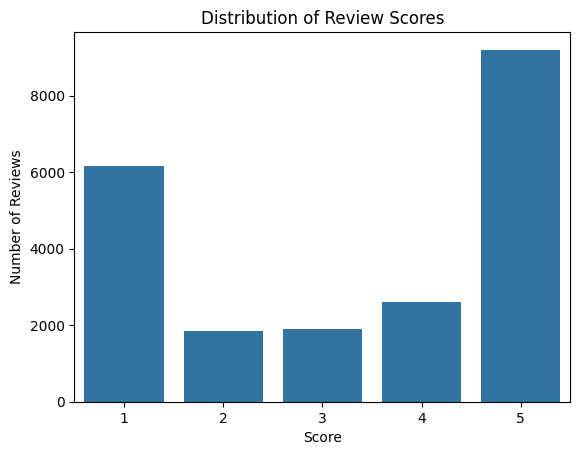

In [23]:
#Erste inhaltliche Analyse
#Warum: Reviews sind fast immer stark positiv verzerrt.
#Das ist wichtig für spätere Modelle
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="score")
plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")
plt.show()

In [24]:
#Score Percentage
score_percentage = df["score"].value_counts(normalize=True).sort_index() * 100
score_percentage.round(2)

score
1    28.35
2     8.54
3     8.77
4    11.96
5    42.37
Name: proportion, dtype: float64

In [25]:
#Review Length Feature
#Warum: Reviewlänge ist ein sehr wichtiges Feature für NLP
df["review_length"] = df["content"].str.len()

In [26]:
#Review Length Statistik
#Hier sehen wir durchschnittliche Länge und extreme Reviews
df["review_length"].describe()

count    21718.000000
mean       127.712174
std        130.002921
min          1.000000
25%         31.000000
50%         80.000000
75%        181.000000
max       1124.000000
Name: review_length, dtype: float64

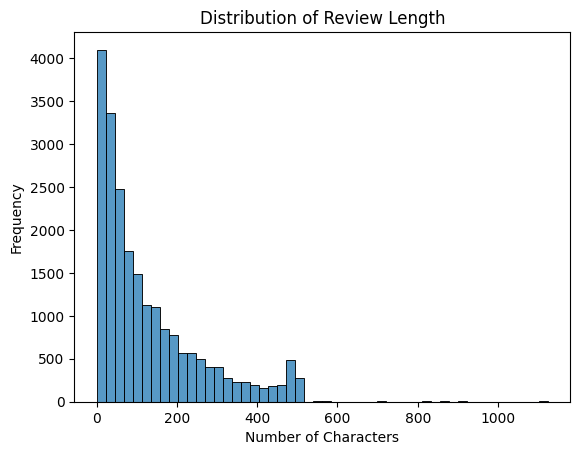

In [27]:
#Review Length Distribution
#Hier sehen wir:
#Wie viele Reviews sind sehr kurz und wie viele sehr lang.
sns.histplot(df["review_length"], bins=50)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

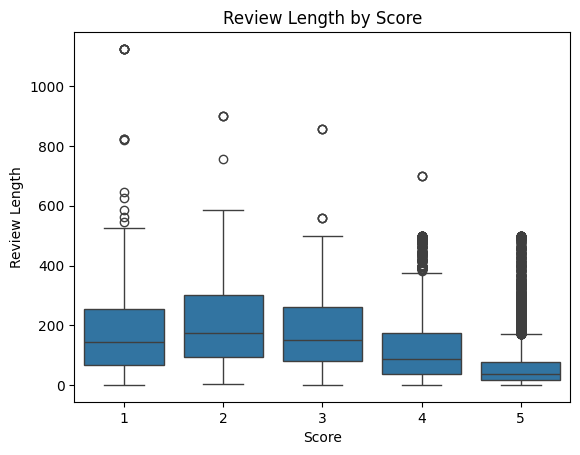

In [28]:
#Review Length vs Score
#Typischer Insight: Negative Reviews sind oft länger
sns.boxplot(x="score", y="review_length", data=df)

plt.title("Review Length by Score")
plt.xlabel("Score")
plt.ylabel("Review Length")

plt.show()

##### Zeitspalte konvertieren
Wir nehmen diese konvertierung vor um im Rahmen der EDA Zeitoperationen durchzuführen

In [29]:
df["at"] = pd.to_datetime(df["at"])

In [30]:
#Reviews pro Jahr
df["year"] = df["at"].dt.year
df["year"].value_counts().sort_index()

year
2020     496
2021    4809
2022    4205
2023    3900
2024    3975
2025    3984
2026     352
Name: count, dtype: int64

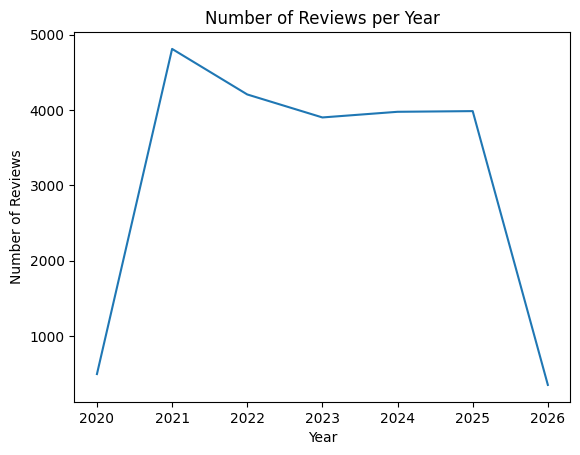

In [31]:
#Zeitliche Entwicklung Plot "Jahr"
#Wir sehen: Wachstum der App und die Aktivitätsphasen po Jahr
df["year"].value_counts().sort_index().plot()

plt.title("Number of Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.show()

In [32]:
#Reviews pro Monat
df["month"] = df["at"].dt.to_period("M")
df["month"].value_counts().sort_index().tail(12)

month
2025-04    448
2025-05    145
2025-06    729
2025-07    263
2025-08    189
2025-09    170
2025-10    240
2025-11    417
2025-12    612
2026-01    232
2026-02     76
2026-03     44
Freq: M, Name: count, dtype: int64

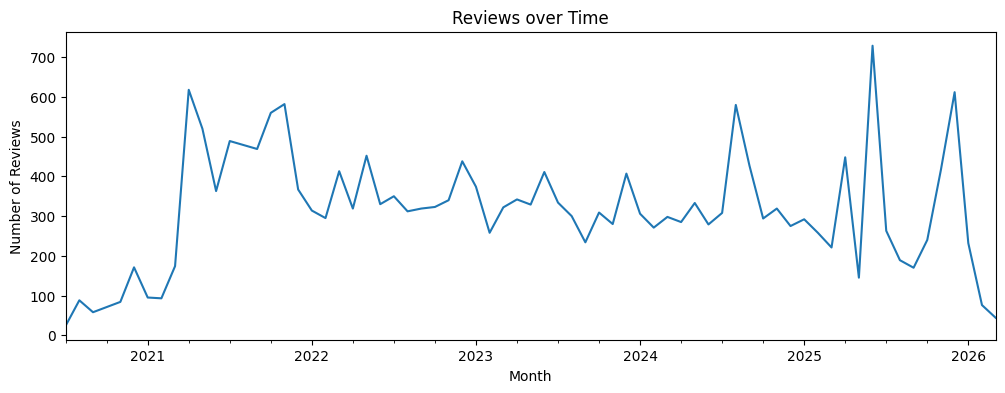

In [33]:
#Zeitliche Entwicklung Plot "Monat"
#Wir sehen: Wachstum der App und die Aktivitätsphasen pro Monat
df["month"].value_counts().sort_index().plot(figsize=(12,4))

plt.title("Reviews over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.show()

In [34]:
#Word Count Feature
#Warum: Für NLP besser als Zeichen
df["word_count"] = df["content"].str.split().str.len()

In [35]:
#Word Count Statistik
df["word_count"].describe()

count    21718.000000
mean        22.387375
std         22.869639
min          1.000000
25%          5.000000
50%         14.000000
75%         32.000000
max        199.000000
Name: word_count, dtype: float64

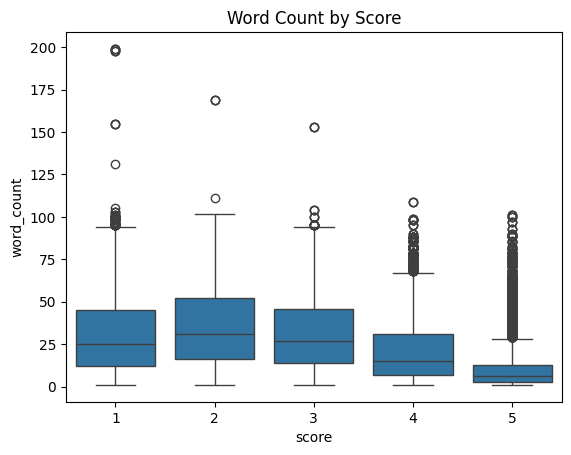

In [36]:
#Word Count vs Score
#Insight: Negatie Reviews sind oft ausführlicher
sns.boxplot(x="score", y="word_count", data=df)
plt.title("Word Count by Score")
plt.show()

##### Wir führen ein leichtes Text-Cleaning durch (Lowercase,Entfernung von Stopwords und Satzzeichen),um aussagekräftigere Wortfreuqenzen zu analysieren.

In [89]:
import nltk
from nltk.corpus import stopwords
import string

stopwords_en=set(stopwords.words("english"))
stopwords_de=set(stopwords.words("german"))
stop_words = stopwords_en.union(stopwords_de)

In [90]:
#Hier entfernen wir zusätzlich BMW-spezifische Wörter
domain_stopwords = {"bmw", "app", "car", "vehicle"}
stop_words = stop_words.union(domain_stopwords)

##### Da der Datensatz aus Bewertungen der BMW-APP besteht, wurden domänenspezifische Wörter wie "bmw", "app", und "car", "vehicle" entfernt, um den Fokus auf informativere Begriffe zu legen, die tatsächliche Nutzerprobleme und Erfahrungen widerspiegeln.

In [91]:
#Wichtige Sentiment Wörter behalten
#Diese Wörter sollte man nicht entfernen, weil sie für Sentiment wichtig sind
stop_words=stop_words - {"not","no", "nicht", "kein"}

In [92]:
#Cleaning-Funktion
import string

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('','', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [93]:
#Neue Spalte für EDA
df["content_clean"] =df["content"].apply(clean_text)
all_words = " ".join(df["content_clean"]).split()

In [94]:
#Häufigste Wörter ohne Filter nach Positiv / Neutral / Negativ (erste NLP Exploration) 
#Wir schauen uns die 20 häufigsten Wörter an im gesamten Dataset
from collections import Counter

all_words = " ".join(df["content_clean"]).split()
word_freq_all = Counter(all_words)
word_freq_all.most_common(20)

[('not', 3568),
 ('nicht', 3126),
 ('update', 2301),
 ('great', 2041),
 ('use', 1990),
 ('good', 1781),
 ('no', 1658),
 ('time', 1304),
 ('works', 1276),
 ('mehr', 1190),
 ('work', 1159),
 ('funktioniert', 1150),
 ('useful', 1097),
 ('cant', 1075),
 ('charging', 1024),
 ('doesnt', 1017),
 ('easy', 1015),
 ('like', 986),
 ('features', 967),
 ('status', 938)]

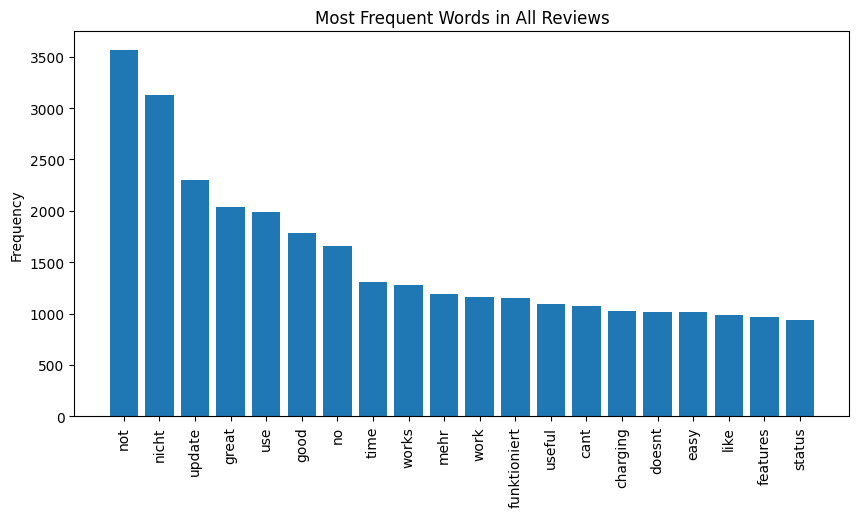

In [95]:
#Plot der häufigsten Wörter ohne Filter nach Positiv / Negativ
top_words = word_freq_all.most_common(20)

words, counts = zip(*top_words)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Most Frequent Words in All Reviews")
plt.ylabel("Frequency")
plt.show()

In [96]:
#Positive / Neutrale / Negative Reviews definieren
positive_reviews = df[df["score"] >= 4]
neutral_reviews = df[df["score"] == 3]
negative_reviews = df[df["score"] <= 2]

print("Positive reviews:", positive_reviews.shape[0])
print("Neutral reviews:", neutral_reviews.shape[0])
print("Negative reviews:", negative_reviews.shape[0])

Positive reviews: 11801
Neutral reviews: 1906
Negative reviews: 8014


In [97]:
#Häufigste Wörter in positiven Reviews
positive_words = " ".join(positive_reviews["content_clean"]).split()
word_freq_positive = Counter(positive_words)
word_freq_positive.most_common(20)

[('great', 1773),
 ('good', 1283),
 ('use', 1060),
 ('easy', 978),
 ('useful', 906),
 ('works', 732),
 ('not', 613),
 ('well', 596),
 ('features', 532),
 ('excellent', 517),
 ('information', 476),
 ('update', 475),
 ('funktioniert', 471),
 ('nicht', 467),
 ('gut', 467),
 ('super', 451),
 ('like', 441),
 ('status', 437),
 ('charging', 416),
 ('would', 402)]

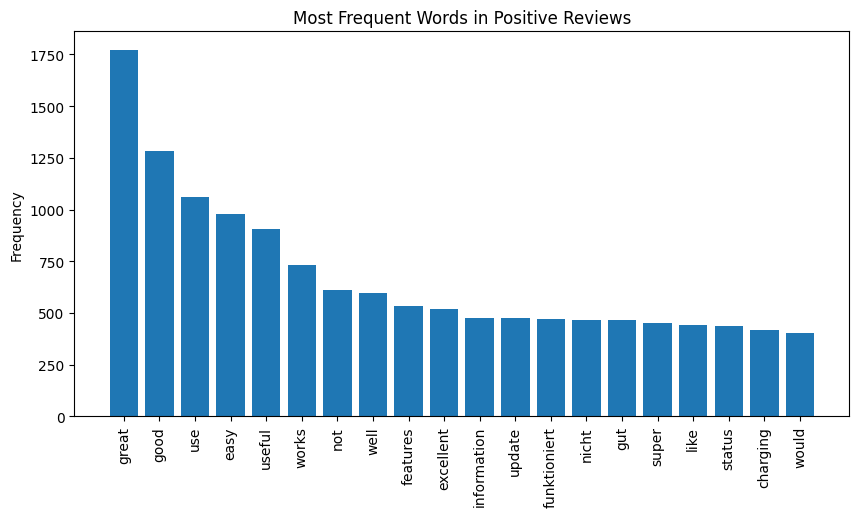

In [98]:
#Plot positive Wörter
top_positive = word_freq_positive.most_common(20)

words_pos, counts_pos = zip(*top_positive)

plt.figure(figsize=(10,5))
plt.bar(words_pos, counts_pos)
plt.xticks(rotation=90)
plt.title("Most Frequent Words in Positive Reviews")
plt.ylabel("Frequency")
plt.show()

##### Wir stellen hier fest, dass beide Diagramme sowohl ohne Filtern und mit positivem Review Filter, die Wörter identisch sind. Die Inhalte sind somit nicht besonders hilfreich. Hierzu werden wir im 03_preprocessing.ipynb Notebook die Stopwords entfernen.

In [99]:
#Häufigste Wörter in neutralen Reviews
neutral_words = " ".join(neutral_reviews["content_clean"]).split()
word_freq_neutral = Counter(neutral_words)
word_freq_neutral.most_common(20)

[('not', 521),
 ('nicht', 420),
 ('update', 332),
 ('time', 198),
 ('good', 186),
 ('no', 168),
 ('charging', 163),
 ('would', 156),
 ('mehr', 148),
 ('connected', 146),
 ('new', 142),
 ('use', 138),
 ('works', 138),
 ('status', 136),
 ('doesnt', 129),
 ('work', 123),
 ('cant', 117),
 ('please', 117),
 ('ok', 116),
 ('like', 115)]

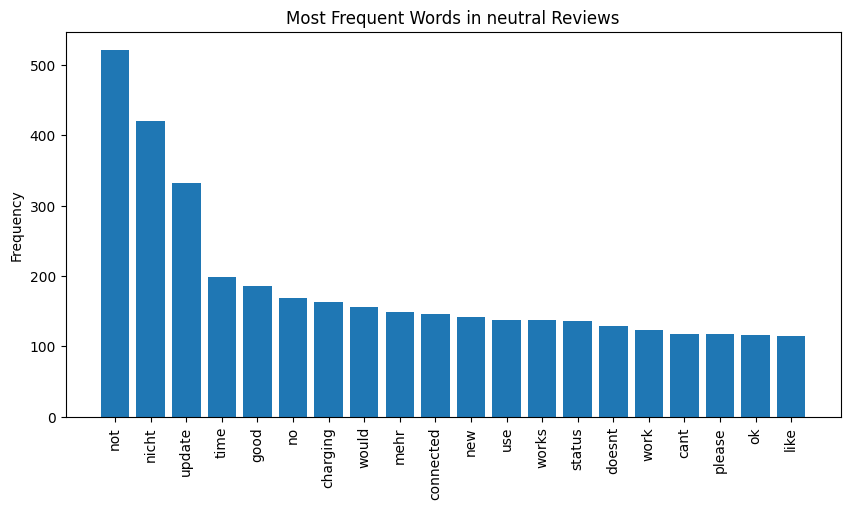

In [100]:
#Plot neutrale Wörter
top_neutral = word_freq_neutral.most_common(20)

words_neutral, counts_neutral = zip(*top_neutral)

plt.figure(figsize=(10,5))
plt.bar(words_neutral, counts_neutral)
plt.xticks(rotation=90)
plt.title("Most Frequent Words in neutral Reviews")
plt.ylabel("Frequency")
plt.show()

In [101]:
#Häufigste Wörter in negativen Reviews
negative_words = " ".join(negative_reviews["content_clean"]).split()
word_freq_negative = Counter(negative_words)
word_freq_negative.most_common(20)

[('not', 2434),
 ('nicht', 2239),
 ('update', 1494),
 ('no', 1240),
 ('mehr', 840),
 ('time', 821),
 ('cant', 808),
 ('use', 792),
 ('doesnt', 786),
 ('work', 784),
 ('new', 606),
 ('even', 592),
 ('funktioniert', 578),
 ('connected', 567),
 ('working', 549),
 ('login', 548),
 ('one', 537),
 ('phone', 513),
 ('still', 504),
 ('android', 461)]

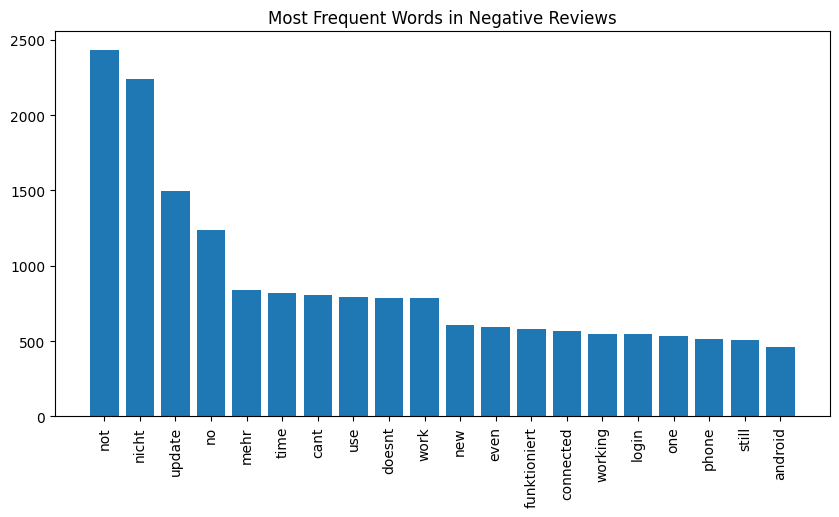

In [102]:
#Plot negative Wörter
top_negative = word_freq_negative.most_common(20)

words_neg, counts_neg = zip(*top_negative)

plt.figure(figsize=(10,5))
plt.bar(words_neg, counts_neg)
plt.xticks(rotation=90)
plt.title("Most Frequent Words in Negative Reviews")
plt.show()

##### Beobachtungen

Der Vergleich der häufigsten Wörter in den verschiedenen Review Kategorien liefert Einblicke in wiederkehrende Themen:
- **Positive reviews** enthalten häufig Wörter, die Zufriedenheit, Lob oder eine gute Nutzererfahrung ausdrücken.
- **Neutrale reviews** enthalten meist beschreibende oder sachliche Begriffe und spiegeln oft gemischte Erfahrungen wider, bei denen sowohl positive als auch negative Aspekte erwähnt werden. 
- **Negative reviews** enthalten häufig Begriffe, die auf Probleme, Schwierigkeiten oder Unzufriedenheit hinweisen.

Diese Analyse hilft dabei, sprachliche Muster zu erkennen, die mit unterschiedlichen Sentiment-KAtegorien verbunden sind und ermöglicht es, typische Themen und potenzielle Schwachstellen im Produkt oder in der Nutzererfahrung zu identifizieren.

##### TO DO´S im PREPROCESSING
- Entferne die Duplikate
- Prüfe das Datenset
- Entferne Zeilen ohne Review
- Prüfe das Dataset
- Prüfe die Spaltennamen
- Entferne nicht benötigte Spalten
- Prüfe erneut das Dataset
- Speichere den bereinigten Datenset mit "clean_reviews"
- Prüfe abschließend erneut Dataset

##### Nun installieren wir zunächst wordcloud (pip install wordcloud) und erstellen eine Wordcloud

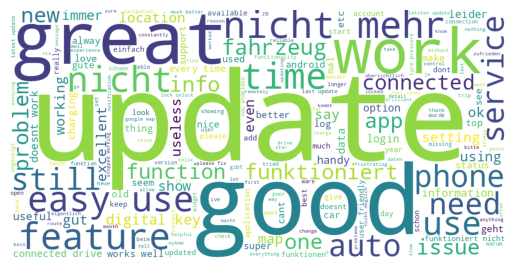

In [105]:
from wordcloud import WordCloud

text= " ".join(filtered_words)
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

##### Wir schauen uns jetzt nochmal die Rating Distribution und die Review Length Distribution an. Also Wie viele Reviews sind 1 Stern, 2 Sterne, 3 Sterne, 4 Sterne, 5 Sterne? Daraus sehen wir wie zufrieden die Nutzer sind. Und Kurze Reviews vs lange Problemberichte.

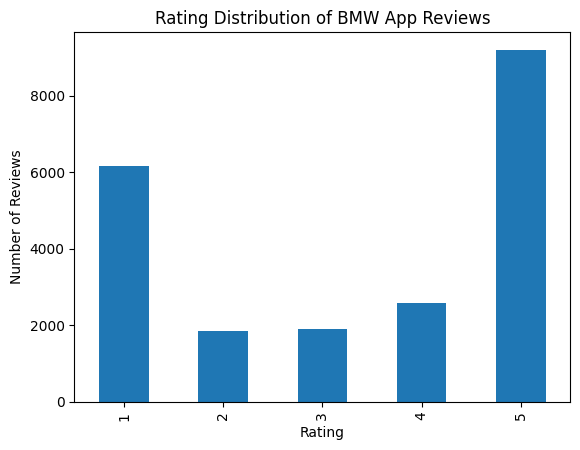

In [106]:
import matplotlib.pyplot as plt
df["score"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution of BMW App Reviews")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

##### Wir sehen zwar dass der größte teil der Nutzer mit der App zufrieden ist allerdings ist die Anzahl der unzufriedenen Nutzer ebenfalls hoch mit über 4000 reviews.

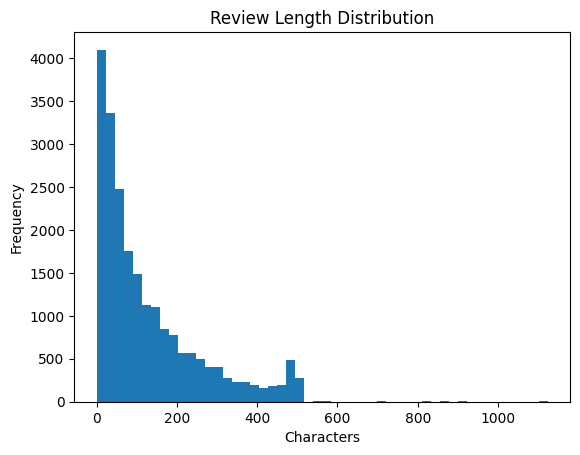

In [107]:
df["review_length"]= df["content"].str.len()
plt.hist(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

##### In dem Diagramm oben sehen wir dass eine stark rechtsschiefe Verteilung vorliegt. Das bedeutet, dass viele kurze Reviews und wenige lange Reviews vorhanden sind. Dies ist üblich für app reviews da Nutzer oftmals nur kurz ihre Meinung hinterlassen statt lange Problemberichte.

##### Nachfolgend schauen wir uns die most negative words an. Hierzu filtern wir nach 2 oder weniger Sternen und schauen uns dort die häufigsten Wörter an.

##### Die Key Insights aus dem EDA
- Die meisten reviews nennen Probleme mit login, connectivity und update.
- Negative reviews erwähnen überwiegend "login", "update", "connection".
- Reviews sind meistens kurz formuliert.
- Die Anzahl der 1 Sterne Rating ist relativ hoch.

##### Zusätzlich ergänzen wir zu unserem EDA die Zeitverlauf Analyse unter Berücksichtigung der Updates.Hierzu nutzen wir die aus dem preprocessing bereinigten Daten.

In [112]:
df = pd.read_csv("../data/BMW/preprocessed_reviews.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10509 entries, 0 to 10508
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10509 non-null  object
 1   content               10509 non-null  object
 2   score                 10509 non-null  int64 
 3   thumbsUpCount         10509 non-null  int64 
 4   reviewCreatedVersion  9953 non-null   object
 5   at                    10509 non-null  object
 6   appVersion            9953 non-null   object
 7   company               10509 non-null  object
 8   clean_text            10498 non-null  object
 9   tokens                10509 non-null  object
 10  lemmatized_text       10498 non-null  object
dtypes: int64(2), object(9)
memory usage: 903.2+ KB


##### Im ersten Schritt schauen wir uns den Review Zeitverlauf an

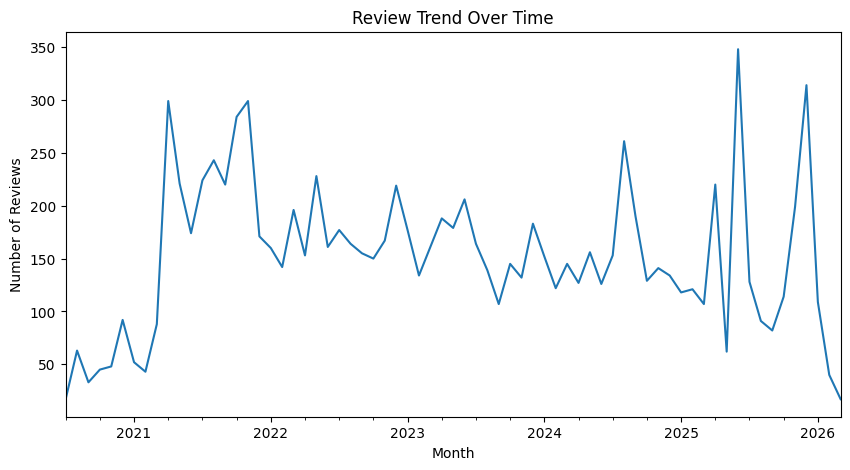

In [113]:
df["at"]=pd.to_datetime(df["at"])
reviews_per_month=df.groupby(df["at"].dt.to_period("M")).size()
reviews_per_month.plot(figsize=(10,5))
plt.title("Review Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

##### Im zweiten Schritt analysieren wir die Versionen

In [114]:
#Reviews pro App Version analysieren. Wie oft kommt jede Version vor?
df["appVersion"].value_counts()

appVersion
1.6.2     428
3.3.1     367
4.7.3     352
1.5.2     335
2.7.0     321
         ... 
3.11.4      2
3.11.0      1
5.11.5      1
5.11.0      1
4.3.0       1
Name: count, Length: 102, dtype: int64

In [115]:
#Reviews sortiert nach Zeit 
df.groupby("appVersion")["at"].min().sort_values()

appVersion
1.0.0    2020-07-27 15:47:02
1.0.1    2020-09-08 23:36:40
1.1.0    2020-10-12 21:04:02
1.2.0    2020-11-30 18:05:18
1.2.1    2020-12-08 09:59:34
                 ...        
5.11.1   2025-11-21 14:12:50
5.11.2   2025-12-01 18:14:32
5.11.3   2025-12-04 19:05:16
5.11.4   2026-01-26 22:20:15
5.11.5   2026-03-02 18:50:10
Name: at, Length: 102, dtype: datetime64[ns]

In [116]:
#Durchschnittliche Rating pro Version
df.groupby("appVersion")["score"].mean().sort_values()

appVersion
2.9.0     1.750000
5.9.0     1.818182
1.3.3     1.892857
5.9.1     2.000000
1.3.2     2.287129
            ...   
4.7.2     4.528302
4.7.0     5.000000
3.11.4    5.000000
4.3.0     5.000000
3.11.0    5.000000
Name: score, Length: 102, dtype: float64

In [117]:
#Durchschnittliches Rating pro Monat
rating_over_time= df.set_index("at").resample("M")["score"].mean()

/var/folders/19/zb4149m55_7gpwbwlsr01jdh0000gn/T/ipykernel_92367/3844148021.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rating_over_time= df.set_index("at").resample("M")["score"].mean()


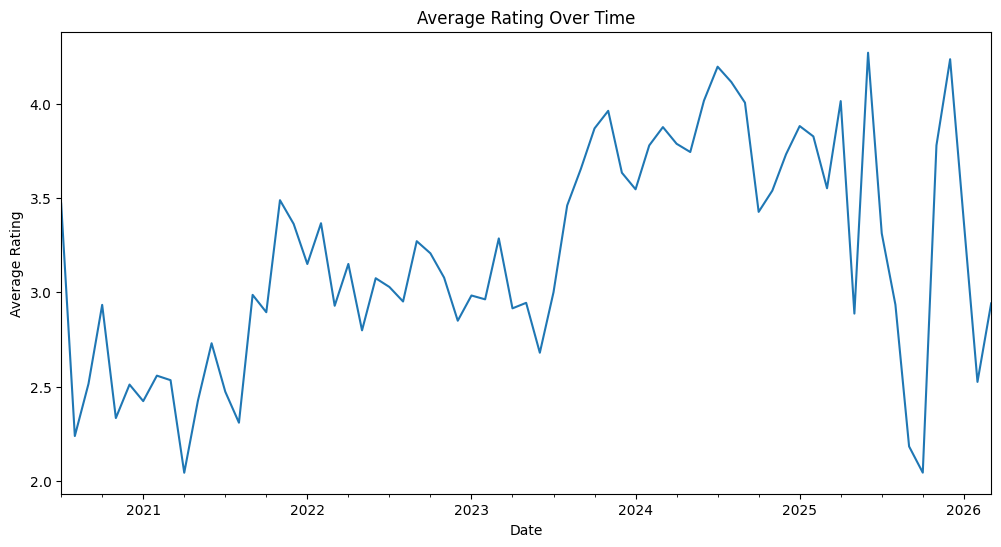

In [118]:
#Plot erstellen
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
rating_over_time.plot()
plt.title("Average Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.show()

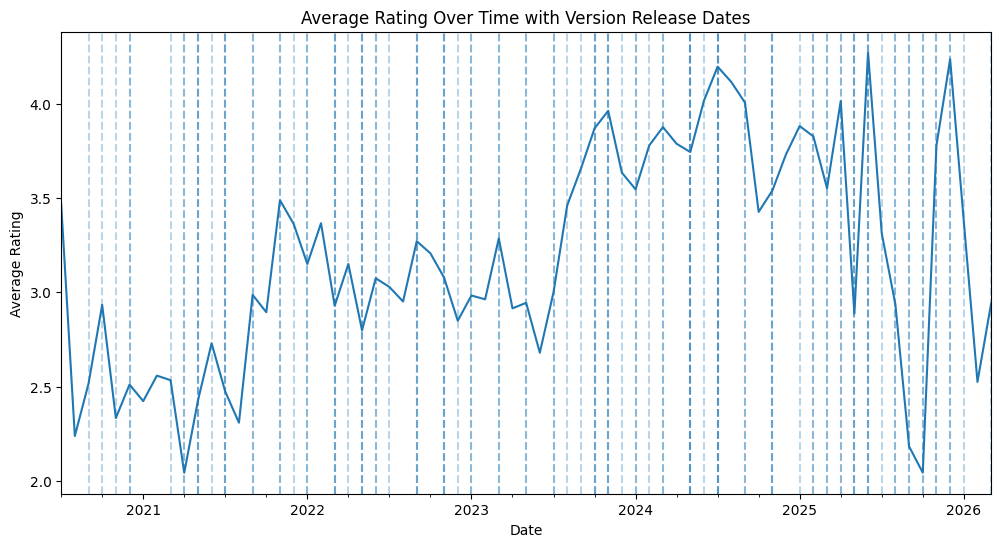

In [119]:
#Jetzt markieren wir erste Reviews einer Version
verion_dates= df.groupby("appVersion")["at"].min().sort_values()
plt.figure(figsize=(12,6))
rating_over_time.plot()
for date in verion_dates:
    plt.axvline(date, linestyle="--", alpha=0.3)

plt.title("Average Rating Over Time with Version Release Dates")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.show()

##### Wir haben festgestellt, dass jedes Update unterschiedlcihe Anzahl an Revies hat. Dies würde zu unplausiblen Auswertungen führen, da ein Update mit nur 1 Review nicht gleichzusetzen ist mit einem Update mit >=50 Reviews.Demzufolge entfernen wir Versionen mit sehr wenigen Reviews. Eine gute wissenschaftliche Regel für stabile Aussagen ist mindestens 30-50 Reviews pro Version. 

/var/folders/19/zb4149m55_7gpwbwlsr01jdh0000gn/T/ipykernel_92367/1715123705.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rating_over_time= df_filtered.set_index("at").resample("M")["score"].mean()


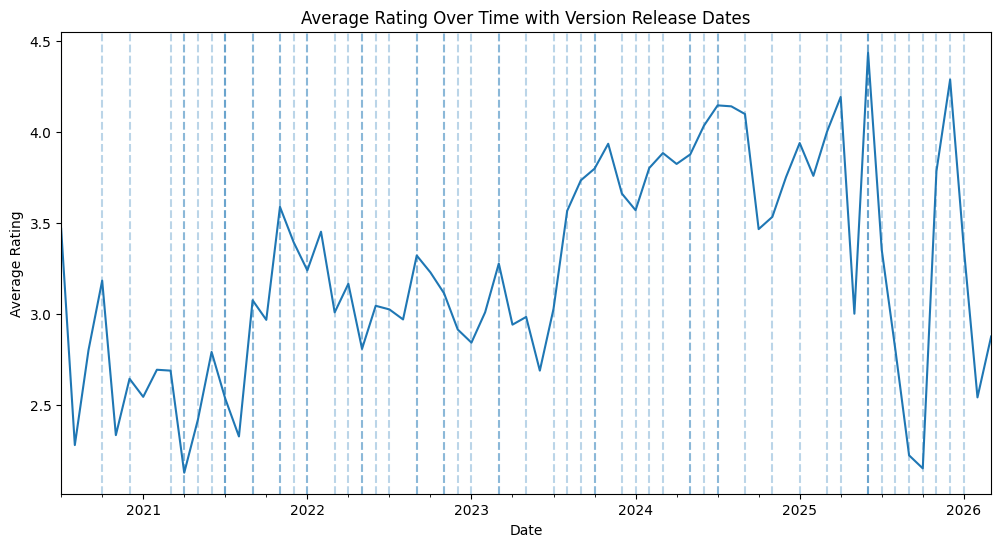

In [120]:
version_counts=df["appVersion"].value_counts()
valid_versions= version_counts[version_counts>50].index
df_filtered=df[df["appVersion"].isin(valid_versions)]

#Jetzt markieren wir erste Reviews einer Version
rating_over_time= df_filtered.set_index("at").resample("M")["score"].mean()
version_dates= df_filtered.groupby("appVersion")["at"].min().sort_values()
plt.figure(figsize=(12,6))
rating_over_time.plot()
for date in version_dates:
    plt.axvline(date, linestyle="--", alpha=0.3)

plt.title("Average Rating Over Time with Version Release Dates")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.show()

In [121]:
df_filtered["appVersion"].value_counts()

appVersion
1.6.2    428
3.3.1    367
4.7.3    352
1.5.2    335
2.7.0    321
        ... 
1.5.1     53
4.7.2     53
5.7.1     53
1.7.3     51
4.5.1     51
Name: count, Length: 62, dtype: int64

In [122]:
df_filtered.shape

(9086, 11)